## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [139]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [140]:
job_id = 420#261#int(sys.argv[1])

In [141]:
in_dir = project_dir / "results"
out_dir = project_dir / "results" / "data_optmap"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [142]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY JOB BATCHES
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level, map_seed)`

In [143]:
# FULL BATCH
seed_list = np.arange(n_seeds_traj)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]

job_list_all_mice = []
for mouse_id in mouse_ids:
    job_list_mouse = [((1,mouse_id,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
    job_list_all_mice.extend(job_list_mouse)

# pack
job_batch_full = {i+1: job for i, job in enumerate(job_list_rand + job_list_all_mice)}

# print
len(job_batch_full)

520

## JOB BATCH TO RUN

In [144]:
job_batch = job_batch_full

## PREP
### setting up belief distribution propagation

In [145]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## LOAD JOB

In [146]:
# check if the saved file exists
dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
dat_exists = os.path.exists(dat_path)
dat_exists

True

In [147]:
key, pi_level = job_batch[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
pi = pi_all[pi_level]

In [ ]:
# # override (single)
# dat_exists = False
# job = ((1, 19, 5), 70)
# dat_path = out_dir / f"dat_map_{job}"

# key, pi_level = job
# s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
# pi = pi_all[pi_level]

In [ ]:
# # override
# if key[0] == 1:
#     dat_exists = False


## RUN: eval random maps

In [149]:
def run_map_optimizer(s_traj, a_traj, occ_map, s_top, pi, eid_removed, eid_remain, schedule):
    '''
    NOTE: deletion-based optimizer
    '''
    # mp
    def run_mp(param):
        # load
        map, chunk_id, chunksize = param
        
        # load chunk of trajectory
        s_traj_r, a_traj_r = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
        
        # eval
        score, score_map, pq_traj = eval_one_map(map, s_traj_r, a_traj_r, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        
        # # get p_map
        # p_map = pq_traj.sum(-1).mean(0)
        return score, score_map
    
    # eval full map
    score_max, _ = run_mp((eid_remain, None, None))
    score_iter = [score_max]
    
    # get initial candidate edges (from zeros of occ_map of full traj)
    s_unoccupied = np.where(occ_map == 0)[0]
    init_eid_cand = get_eid_from_s(s_unoccupied, e_sh_arr)
    if len(s_unoccupied) > 0:
        print(f"{len(init_eid_cand)} unoccupied edges found from full trajectory...")

    # iter
    for iter in np.arange(len(schedule)):
        # load schedule
        n_chunks, chunk_id, chunksize = schedule[iter]
        
        # find candidate edges to remove
        # if iter==0:
        #     _, _, p_map = run_mp((eid_remain, chunk_id, chunksize))
        for subiter in range(n_chunks):
            s_traj_r, _ = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
            eid_cand = get_eid_cand_for_one_iter(eid_remain, init_eid_cand, s_traj_r, e_sh_arr, n_tiles)
            if len(eid_cand) > 0:
                eid_cand_exists = True
                break
            else:
                eid_cand_exists = False
                print(f"chunk {chunk_id} has no candidate edges to remove, trying next chunk...")
                chunk_id = (chunk_id + 1) % n_chunks # override until eid_cand is non-empty
                _, _ = run_mp((eid_remain, chunk_id, chunksize))
        if not eid_cand_exists:
            print(f"no candidate edges found in any chunk, using all remaining edges...")
            eid_cand = eid_remain # if no candidate edges found, use all remaining edges
        
        # eval candidates on one traj chunk
        eid_remain_cand = [eid_remain[eid_remain!=x] for x in eid_cand]
        param = [(x, chunk_id, chunksize) for x in eid_remain_cand]
        with multiprocess.Pool() as p:
            score_cand, _ = zip(*p.map(run_mp, param))
        
        # find top
        idx_top = np.argmax(score_cand)
        eid_top = eid_cand[idx_top] # top to be removed
        score_top = score_cand[idx_top]
        eid_remain = eid_remain_cand[idx_top]
        # p_map = p_map_cand[idx_top]

        # append
        eid_removed.append(eid_top)
        score_iter.append(score_top)
        
        # print
        print(f"iter {iter}: eval {len(eid_cand)} edges, remove edge {eid_top}, score = {score_top:.6f}, chunk_id = {chunk_id}/{n_chunks}")
    return score_iter, eid_removed

def eval_multiple_maps(map_list, s_traj, a_traj, s_top, pi):
    '''
    NOTE: 
    '''
    def run_mp(map):
        score, score_map, _ = eval_one_map(map, s_traj, a_traj, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # mp
    with multiprocess.Pool() as p:
        score_list, score_map_list = zip(*p.map(run_mp, map_list))
    score_list = np.array(score_list)
    return score_list, score_map_list

In [ ]:
## RUN (4m)
if not dat_exists:
    # get optimized map
    print(f'eval on job={job_batch[job_id]}')
    # print(f'eval on job={job}') # override
    # eid_removed = sample_one_randmap(n_edges, map_seed)
    score_iter_full_0, score_map_iter_full_0, eid_removed = pickle.load(open(dat_path, "rb"))
    
    # eval all maps on full trajectory
    print(f'evaluating all maps on full trajectory...')
    map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
    score_iter_full, score_map_iter_full = eval_multiple_maps(map_iter, s_traj, a_traj, s_top, pi)

eval on job=((1, 19, 5), 70)
evaluating all maps on full trajectory...


### DEV

In [ ]:
# mapsize = 74

# # load one iter
# iter_select = list(range(931))[::-1].index(mapsize)
# score_map = score_map_iter_full[iter_select]
# score = score_iter_full[iter_select]

In [ ]:
# score_iter_full[iter_select]

0.715074

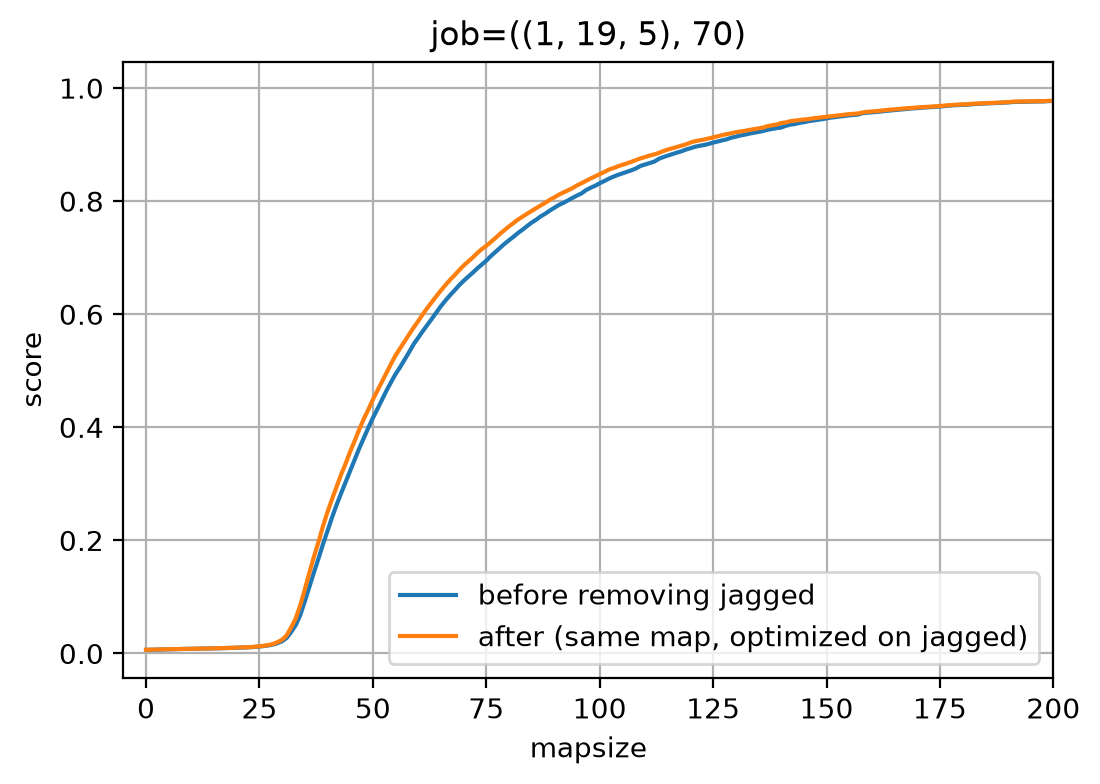

In [ ]:
# mapsize_iter = [len(x) for x in map_iter]

# plt.figure(figsize=(6,4), dpi=200)
# plt.title(f'job={job}')
# plt.plot(mapsize_iter, score_iter_full_0, label='before removing jagged')
# plt.plot(mapsize_iter, score_iter_full, label='after (same map, optimized on jagged)')
# plt.xlabel('mapsize')
# plt.ylabel('score')
# plt.xlim(-5, 200)
# plt.grid()
# plt.legend()

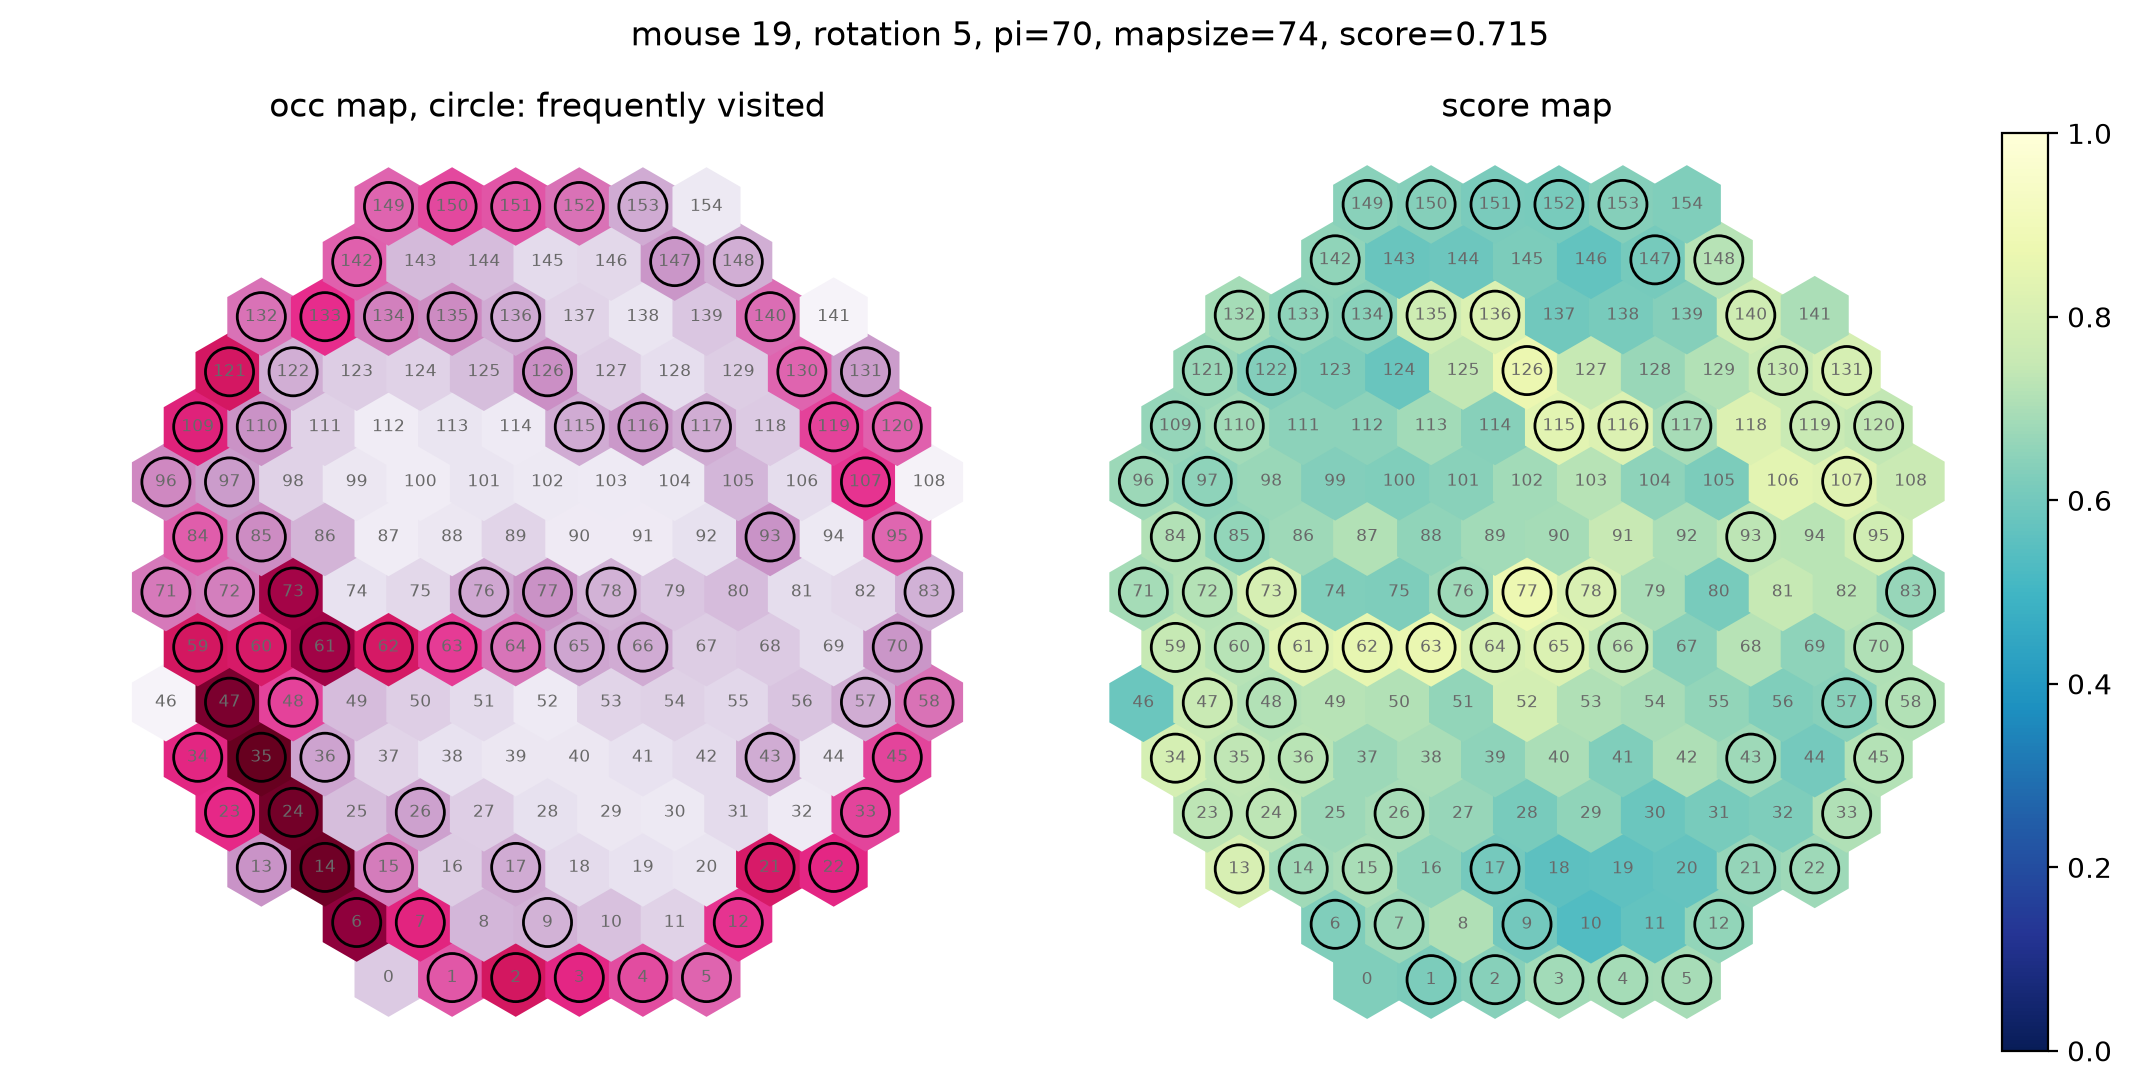

In [ ]:
# hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
# hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# # plot
# plt.figure(figsize=(11,5.5), dpi=200)
# if job[0][0]==1:
#     plt.suptitle(f'mouse {job[0][1]}, rotation {job[0][2]}, pi={job[1]}, mapsize={mapsize}, score={score:.3f}')
# elif job[0][0]==0:
#     plt.suptitle(f'randwalk {job[0][1]}, mapsize={mapsize}, score={score:.3f}')

# plt.subplot(121)
# plt.title('occ map, circle: frequently visited')
# plt.scatter(hex_0_all, hex_1_all, c=occ_map, cmap='PuRd', marker='h', s=800, vmin=0, edgecolor='none')
# plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
# for (x,y), s in xy_s_dict.items():
#     plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
# plt.axis('off')
# plt.axis('equal')

# plt.subplot(122)
# plt.title('score map')
# plt.scatter(hex_0_all, hex_1_all, c=score_map, cmap='YlGnBu_r', marker='h', s=800, vmin=0, vmax=1, edgecolor='none')
# plt.colorbar()
# plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
# for (x,y), s in xy_s_dict.items():
#     plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
# plt.axis('off')
# plt.axis('equal')

# # setting
# plt.axis('off')
# plt.tight_layout()

## PICKLE

In [ ]:
if not dat_exists:
# if True:
    dat_map = score_iter_full, score_map_iter_full, eid_removed
    pickle.dump(dat_map, open(dat_path, "wb"))
    
else:
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))

## TEST

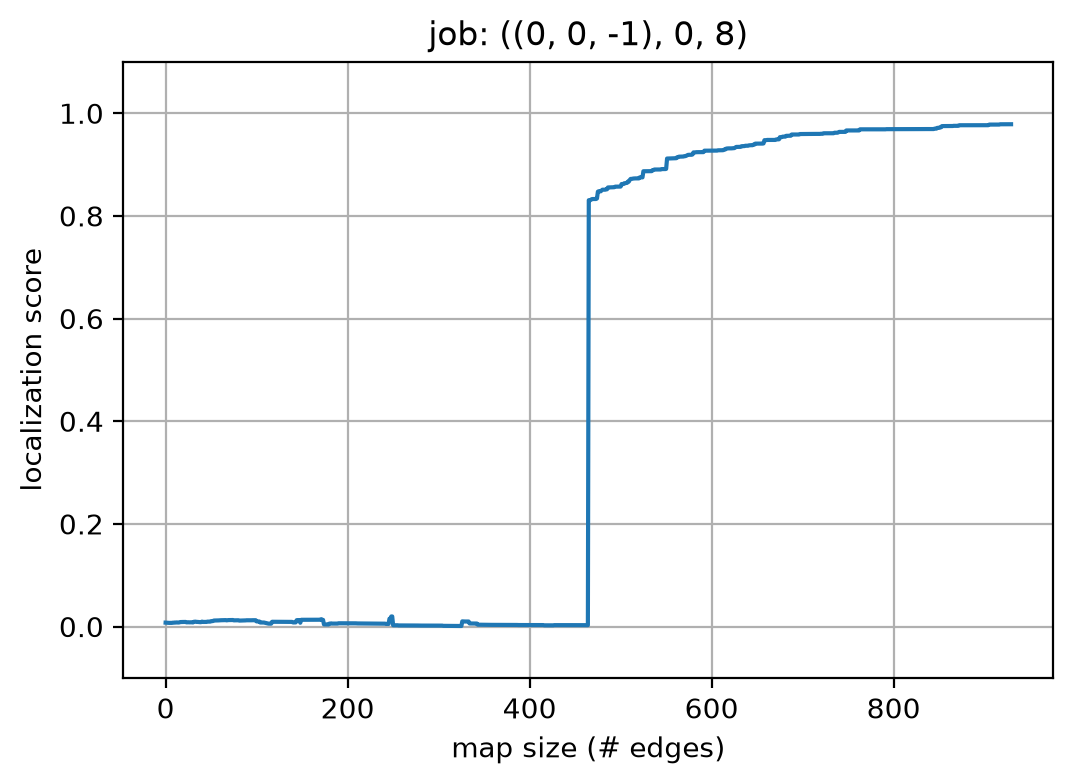

In [23]:
n_plot = 930

# plot
map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
mapsize_iter = [len(x) for x in map_iter]
plt.figure(figsize=(6,4), dpi=200)
plt.title(f"job: {job_batch[job_id]}")
plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()

if not os.path.exists(out_dir / 'plot'):
    os.makedirs(out_dir / 'plot')
plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")

## RERUN

In [156]:
np.where(~np.array([os.path.exists(out_dir / f"dat_map_{y}") for x,y in job_batch.items()]))[0]+1

array([], dtype=int64)